In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import json
import pandas as pd
from ipywidgets import interact, FloatSlider, IntSlider
import yaml
import os
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import importlib


from pathlib import Path

%matplotlib inline

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 16
})

from scipy.stats import norm

# Read Data

In [3]:
campaign_folders = ["AL_4D",        # 0
                    "Random_4D",    # 1
                    "AL_12D",       # 2
                    "Random_12D"    # 3
                    ]

campaign_folder = campaign_folders[0]  # Change this index to load a different campaign folder

def load_campaign_df(folder_name):
    """Load and process data for a given campaign folder."""
    folder_path = os.path.join("campaigns", folder_name)

    in_file = os.path.join(folder_path, f"{folder_name}_campaign_overview.yaml")

    with open(in_file, 'r') as f:
        campaign = yaml.safe_load(f)

    gp_model_list = [config['gp_model'] for config in campaign['configs']]
    merged_df = pd.DataFrame(campaign['runs'])

    gp_model_path = gp_model_list[-1] if gp_model_list[-1] != 'x:x' else 'models.gpmodel_constant_PriorMean:GPModelConstMean'

    csv_file = os.path.join(folder_path, f"{folder_name}_growth_and_rmse_summary_fixedCauchy.csv")
    if os.path.exists(csv_file):
        refellips_file = pd.read_csv(csv_file)
        refellips_file = refellips_file[refellips_file['Lin_GPC_nm'] != 'Lin_GPC_nm'].reset_index(drop=True)
        merged_df['dep_rate_mean'] = pd.to_numeric(refellips_file['Lin_GPC_nm'], errors='coerce')

    merged_df['dep_rate_deviation'] = 0.011

    return merged_df, folder_name, gp_model_path, campaign


# Load primary campaign
merged_df, campaign_label, gp_model_path, campaign = load_campaign_df(campaign_folder)

print("loaded")

loaded


In [4]:
merged_df

,run_id,ALD_prep_time,ALD_purge_flow_rate,ALD_purge_plasma_flow_rate,ALD_purge_time,Ar_plasma_flow_rate,Ar_process_flow_rate,H2_plasma_flow_rate,LC_preset,N2_plasma_flow_rate,...,Initial_thickness,Temperature,dep_rate_fit,dep_rate_mean,dep_rate_direct,dep_rate_deviation,fit_diff_variation,is_prior,from_recommendation_id,campaign_id
0,0t49dprknhsak000c3k693h2qg,2000,5,0,4914,0,50,75,50,0,...,0.48154,150,0.052116,0.068169,0.139254,0.011,3.383906,False,0t49dprjz9tbb000ssqa8azzhg,0t49dprjynzhz000esnegj1jk8
1,0t49dy39mny8k000ng6241k8mw,2000,5,0,4201,0,50,75,50,0,...,4.01500,150,0.133442,0.134729,0.136092,0.011,6.420534,False,0t49dy3989vjz00075v27g1er8,0t49dprjynzhz000esnegj1jk8
2,0t49e65mbdz3v000n2g27rnp10,2000,5,0,1488,0,50,75,50,0,...,7.48570,150,0.062305,0.061114,0.060408,0.011,3.153647,False,0t49e65ktxwe1000xf7hm7ppnc,0t49dprjynzhz000esnegj1jk8
3,0t49ed0xmxvaf000zf6x8d54dm,2000,5,0,225,0,50,75,50,0,...,9.00640,150,0.111005,0.110957,0.111624,0.011,8.642444,False,0t49ed0wysrb3000hzb025dbq0,0t49dprjynzhz000esnegj1jk8
4,0t49em4gx1v1q00040qzs718p8,2000,5,0,1885,0,50,75,50,0,...,11.84100,150,0.159166,0.160743,0.161080,0.011,14.504230,False,0t49em4epxwef000h404n0meaw,0t49dprjynzhz000esnegj1jk8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0t4a5v53txvf3000kdnrwmd2f0,2000,5,0,5999,0,50,75,50,0,...,265.13000,150,0.147367,0.150357,0.144400,0.011,3.623349,False,0t4a5v53fdvrq000z8z7bn9rkm,0t49fgtahnrvv000294qhkf8jm
96,0t4a67ee9dyp90004nqwvh4n0r,2000,5,0,3087,0,50,75,50,0,...,268.73000,150,0.090102,0.089186,0.086400,0.011,2.954690,False,0t4a67edz1rr5000hyqwcgqpam,0t49fgtahnrvv000294qhkf8jm
97,0t4a6h17a5svn000erv7nbh184,2000,5,0,5999,0,50,75,50,0,...,270.82000,150,0.141450,0.139543,0.142400,0.011,3.456001,False,0t4a6h170hwn9000dsnfcj26qr,0t49fgtahnrvv000294qhkf8jm
98,0t4a6wfdfdyn5000raj6xqnmvw,2000,5,0,10,0,50,75,50,0,...,274.34000,150,0.111839,0.111421,0.113600,0.011,2.448045,False,0t4a6wfcynwwf000fzr1ja3qw8,0t49fgtahnrvv000294qhkf8jm


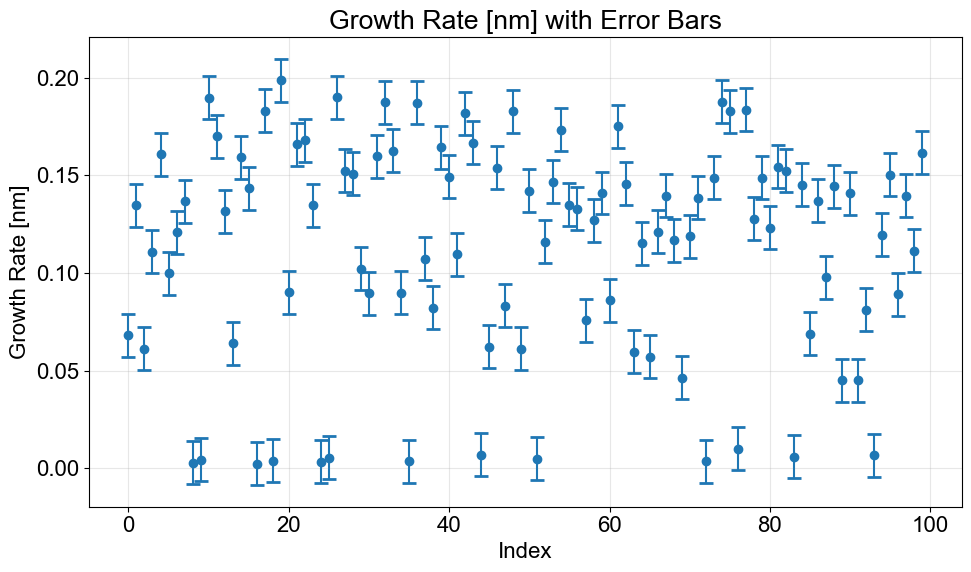

In [5]:
import matplotlib.pyplot as plt

# Create the scatter plot with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(
    range(len(merged_df)),  # x-axis: index
    merged_df['dep_rate_mean'], # refellips_file['Lin_GPC_nm'],  # y-axis
    yerr=merged_df['dep_rate_deviation'] ,  # error bars
    fmt='o',  # marker style (circles)
    capsize=5,  # cap width for error bars
    capthick=2,  # cap thickness
    elinewidth=1.5,  # error bar line width
    markersize=6  # marker size
)

plt.xlabel('Index')
plt.ylabel('Growth Rate [nm]')
plt.title('Growth Rate [nm] with Error Bars')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GP Model Objects

In [6]:
# ########################################
# Do you want to re-fit the GP models or just load and reconstruct them?
re_fit_GP_models = False
# ########################################

def load_from_module_path(path):
    m, c = path.split(":")
    mod = importlib.import_module(m)
    C = getattr(mod, c)
    return mod, C

config = campaign['configs'][-1]
parameter_space_limits = []
for param in config['modeled_params']:
    parameter_space_limits.append(config['param_limits'][param])

# Defining the GP model class from the path
_, GPmodel = load_from_module_path(gp_model_path)

# Determine number of random initialization points based on dimensionality
num_modeled_params = len(config['modeled_params'])
if num_modeled_params == 4:
    num_random_points = 5
elif num_modeled_params == 12:
    num_random_points = 15
else:
    raise ValueError(f"Unexpected number of modeled params: {num_modeled_params}. "
                      f"Expected 4 or 12 — update num_random_points logic if this is intentional.")

# Fit the GP model for each step in the campaign
indices_to_process = range(num_random_points + 1, len(merged_df))

pkl_path = os.path.join("campaigns", campaign_label, "merged_df.pkl")

if re_fit_GP_models:
    hyperparameters_history = []
    iteration_numbers = []

    for i in indices_to_process:
        print(f"Fitting GP model for run index: {i}")
        current_data = merged_df.iloc[:i+1]
        merged_df.at[i, 'gpmodel'] = GPmodel(current_data,
                                            input_names=config['modeled_params'], output_name='dep_rate_mean',
                                            parameter_space_limits=parameter_space_limits,
                                            output_deviation_variable='dep_rate_deviation',
                                            train_method="global",
                                            train_max_iter=4000)

        current_hps = merged_df.at[i, 'gpmodel'].current_trained_hps
        hyperparameters_history.append(current_hps.copy())
        iteration_numbers.append(i)

    merged_df['gp_hyperparameters'] = None
    for i in indices_to_process:
        if 'gpmodel' in merged_df.columns and pd.notna(merged_df.at[i, 'gpmodel']):
            merged_df.at[i, 'gp_hyperparameters'] = merged_df.at[i, 'gpmodel'].current_trained_hps.copy()

    df_to_save = merged_df.drop(columns=['gpmodel'], errors='ignore')
    df_to_save.to_pickle(pkl_path)

else:
    # Load and reconstruct
    merged_df = pd.read_pickle(pkl_path)
    merged_df['gpmodel'] = None

    for i in merged_df[merged_df['gp_hyperparameters'].notna()].index:
        print(f"Reconstructing GP model for run index: {i}")
        current_data = merged_df.iloc[:i+1]
        merged_df.at[i, 'gpmodel'] = GPmodel(
            current_data,
            input_names=config['modeled_params'],
            output_name='dep_rate_mean',
            parameter_space_limits=parameter_space_limits,
            output_deviation_variable='dep_rate_deviation',
            prev_trained_GP_hps=merged_df.at[i, 'gp_hyperparameters'],
            train_method="global",
            train_max_iter=4000
        )

Reconstructing GP model for run index: 6
Reconstructing GP model for run index: 7
Reconstructing GP model for run index: 8
Reconstructing GP model for run index: 9
Reconstructing GP model for run index: 10
Reconstructing GP model for run index: 11
Reconstructing GP model for run index: 12
Reconstructing GP model for run index: 13
Reconstructing GP model for run index: 14
Reconstructing GP model for run index: 15
Reconstructing GP model for run index: 16
Reconstructing GP model for run index: 17
Reconstructing GP model for run index: 18
Reconstructing GP model for run index: 19
Reconstructing GP model for run index: 20
Reconstructing GP model for run index: 21
Reconstructing GP model for run index: 22
Reconstructing GP model for run index: 23
Reconstructing GP model for run index: 24
Reconstructing GP model for run index: 25
Reconstructing GP model for run index: 26
Reconstructing GP model for run index: 27
Reconstructing GP model for run index: 28
Reconstructing GP model for run index:

# Information gain computation

In [7]:
recalc_exp_info_gain = False  # Set to True if you want to recalculate RMSE, False to load from CSV

# Define CSV filename
csv_filename = f"campaigns/{campaign_label}/exp_info_gain.csv"

################################################################
if len(config['modeled_params'])<5: 
    # Define the points in space where we want to evaluate the GP models for information gain calculation
    # Testing data
    n_test_points_per_dim = 8
    test_grids = []
    for i, limit in enumerate(parameter_space_limits):
        test_grids.append(np.linspace(limit[0], limit[1], n_test_points_per_dim))

    # Create meshgrid for all 4 dimensions
    meshes = np.meshgrid(*test_grids, indexing='ij')

    # Flatten and combine into test points
    x_test = np.column_stack([mesh.ravel() for mesh in meshes])

    # Convert to DataFrame
    x_test_df = pd.DataFrame(x_test, columns=config['modeled_params'])

    latest_gpmodel = merged_df.at[99, 'gpmodel']

    x_test_df_normalized = x_test_df.copy()

    x_test_df_normalized[config['modeled_params']] = latest_gpmodel.scaler.transform(x_test_df[config['modeled_params']])

    x_test_normalized = np.array(x_test_df_normalized)

else:
    x_test_normalized = None

################################################################

if recalc_exp_info_gain:
    print("🔄 Recalculating Information Gain for all models...")

    # Initialize the column
    merged_df['information_gain'] = None
    
    # Check if CSV exists and delete it for a fresh start
    os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
    if os.path.exists(csv_filename):
        os.remove(csv_filename)

    # Calculate Information Gain for each model
    for i in indices_to_process:

        print(f"🔬 Calculating Information Gain for run {i}")

        gpmodel = merged_df.at[i, 'gpmodel']
        
        ################################################################
        # Information gain

        if i > num_random_points + 1 and len(config['modeled_params']) < 5: 
            prev_gpmodel = merged_df.at[i-1, 'gpmodel']
            current_gpmodel = merged_df.at[i, 'gpmodel']

            my_posterior_mean_GP1 = prev_gpmodel.my_gpo.posterior_mean(x_test_normalized)["m(x)"]
            my_posterior_covariance_GP1 = prev_gpmodel.my_gpo.posterior_covariance(x_test_normalized, add_noise=False)['S'] + 1e-5 * np.eye(len(x_test_normalized))
            
            my_posterior_mean_GP2 = current_gpmodel.my_gpo.posterior_mean(x_test_normalized)["m(x)"]
            my_posterior_covariance_GP2 = current_gpmodel.my_gpo.posterior_covariance(x_test_normalized, add_noise=False)['S'] + 1e-5 * np.eye(len(x_test_normalized))
            
            info_gain = current_gpmodel.my_gpo.posterior.kl_div(my_posterior_mean_GP1, my_posterior_mean_GP2, my_posterior_covariance_GP1, my_posterior_covariance_GP2)

            merged_df.at[i, 'information_gain'] = info_gain
                            
        else:
            # For early runs (i <= 6) OR high-dimensional cases (>= 5 params)
            merged_df.at[i, 'information_gain'] = np.nan

        # ✅ Save all results to CSV including SEM - AFTER all calculations are done
        print("💾 Saving all calculated metrics to CSV...")
        all_metrics = merged_df['information_gain'].copy()
        all_metrics.to_csv(csv_filename, index=True)


else:
    print("📖 Loading all metrics from CSV...")
    
    if os.path.exists(csv_filename):
        all_metrics = pd.read_csv(csv_filename, index_col=0)
        
        # Add back to merged_df
        for col in ['information_gain']:
            if col in all_metrics.columns:
                merged_df[col] = all_metrics[col]
    
    print("📖 Loaded")
 

📖 Loading all metrics from CSV...
📖 Loaded


✅ Loaded AL_4D: (100, 1)
✅ Loaded Random_4D: (100, 1)


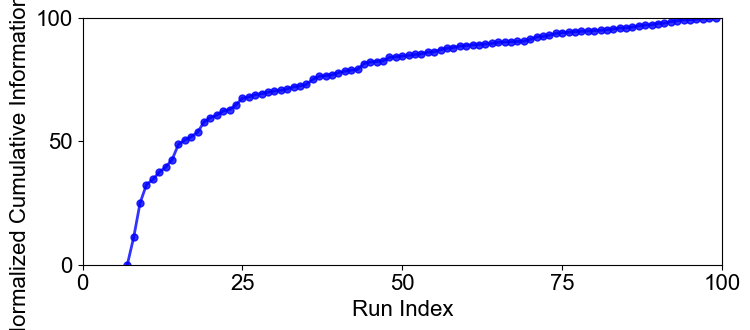

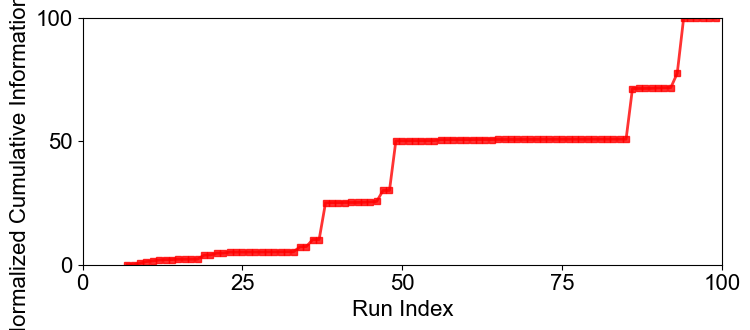

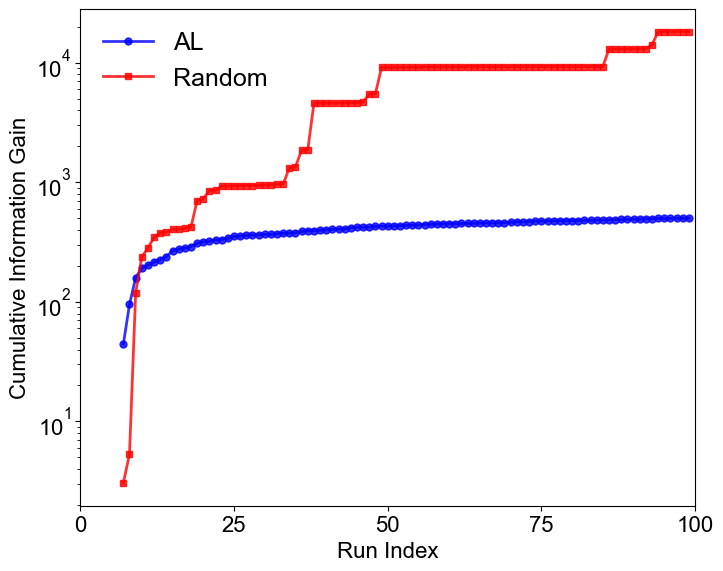

In [8]:
# ✅ LOAD DATA FOR BOTH CAMPAIGNS
campaign_data = {}
campaign_labels = {'Random_4D': 'Random', 'AL_4D': 'AL', 'Random_12D': 'Random', 'AL_12D': 'AL'}

# Find experimental data from BO and random campaigns
if campaign_label in ['AL_4D', 'Random_4D']:
    campaigns_to_compare = ['AL_4D', 'Random_4D']
elif campaign_label in ['AL_12D', 'Random_12D']:
    campaigns_to_compare = ['AL_12D', 'Random_12D']

for folder_name_current in campaigns_to_compare:
    csv_file = f"campaigns/{folder_name_current}/exp_info_gain.csv"
    if os.path.exists(csv_file):
        campaign_data[folder_name_current] = pd.read_csv(csv_file, index_col=0)
        print(f"✅ Loaded {folder_name_current}: {campaign_data[folder_name_current].shape}")

colors = ['blue', 'red']
markers = ['o', 's']

is_4d = len(config['modeled_params']) < 5

if is_4d:

    for i, campaign_num_current in enumerate(campaigns_to_compare):
            if campaign_num_current in campaign_data and 'information_gain' in campaign_data[campaign_num_current].columns:
                data = campaign_data[campaign_num_current]['information_gain'].dropna()
                if len(data) > 0:
                    cumulative_data = data.cumsum()

                    # Normalize from 0 to 100
                    min_val = cumulative_data.min()
                    max_val = cumulative_data.max()
                    normalized_data = 100 * (cumulative_data - min_val) / (max_val - min_val)

                    # New figure for each campaign
                    plt.figure(figsize=(7.6, 3.5))

                    plt.plot(cumulative_data.index, normalized_data.values,
                            color=colors[i], marker=markers[i], linewidth=2, markersize=5,
                            alpha=0.8, label=f'{campaign_labels[campaign_num_current]}')

                    plt.xlabel('Run Index', fontsize=16)
                    plt.ylabel('Normalized Cumulative Information Gain', fontsize=16)
                    plt.tight_layout()
                    plt.ylim(0, 100)
                    plt.xlim(0, 100)
                    plt.xticks([0, 25, 50, 75, 100])
                    plt.yticks([0, 50, 100])

                    plt.show()

    # ✅ PLOT: Cumulative Information Gain (unnormalized, log scale)
    plt.figure(figsize=(7.6, 6))

    for i, folder_name_current in enumerate(campaigns_to_compare):
        if folder_name_current in campaign_data and 'information_gain' in campaign_data[folder_name_current].columns:
            data = campaign_data[folder_name_current]['information_gain'].dropna()
            if len(data) > 0:
                cumulative_data = data.cumsum()

                plt.plot(cumulative_data.index, cumulative_data.values,
                            color=colors[i], marker=markers[i], linewidth=2, markersize=5,
                            alpha=0.8, label=f'{campaign_labels[folder_name_current]}')

    plt.xlabel('Run Index', fontsize=16)
    plt.ylabel('Cumulative Information Gain', fontsize=16)
    plt.tight_layout()
    plt.xlim(0, 100)
    plt.xticks([0, 25, 50, 75, 100])
    plt.yscale('log')
    plt.legend(fontsize=18, loc='upper left', frameon=False)
    plt.show()

# RMSE Calculations of all experimental data

In [9]:
# Extract all releavnt experimental data

all_exp_data_list = []

for folder_name_current in campaigns_to_compare:

    print(f"Loading campaign {folder_name_current}...")

    # Standard loader handles refellips postprocessing directly from the pre-patched files
    merged_df_current, _, _, current_campaign = load_campaign_df(folder_name_current)

    # Extract the modeled params + dep_rate_mean
    config = current_campaign['configs'][0]
    columns_to_extract = config['modeled_params'] + ['dep_rate_mean']

    current_campaign_data = merged_df_current[columns_to_extract].copy()
    current_campaign_data['campaign'] = folder_name_current
    all_exp_data_list.append(current_campaign_data)

# SINGLE COMBINED DATAFRAME
all_exp_data = pd.concat(all_exp_data_list, ignore_index=True)
all_exp_data

Loading campaign AL_4D...
Loading campaign Random_4D...


,plasma_prep_time,precursor_dose_time,plasma_purge_time,ALD_purge_time,dep_rate_mean,campaign
0,1771,255,498,4914,0.068169,AL_4D
1,2805,2257,748,4201,0.134729,AL_4D
2,3507,1171,3438,1488,0.061114,AL_4D
3,3519,3334,4445,225,0.110957,AL_4D
4,3029,5848,1401,1885,0.160743,AL_4D
...,...,...,...,...,...,...
195,1843,307,1901,505,0.011357,Random_4D
196,63,1465,2687,2081,0.079050,Random_4D
197,2826,5355,4816,5901,0.113936,Random_4D
198,2097,1076,3725,2722,0.060893,Random_4D


In [10]:
# Randomly sample 100 sets of 50 points from the pool of experimental data, excluding the first 5 (4d) points of each campaign

resample_sets = False  # Set to True if you want to recalculate RMSE, False to load from JSON

N_SETS = 100
SET_SIZE = 50
SEED = 42

if campaign_label in ['AL_4D', 'Random_4D']:
    N_drop_rows_per_campaign = 5  # Number of rows to drop from each campaign
    prob_dimensionality = 4
elif campaign_label in ['AL_12D', 'Random_12D']:
    N_drop_rows_per_campaign = 15  # Number of rows to drop from each campaign
    prob_dimensionality = 12

OUT_PATH = Path(f"RMSE_heldout_sets_{prob_dimensionality}d.json")


if resample_sets:

    all_exp_data_list = []

    for folder_name_current in campaigns_to_compare:

        print(f"Loading campaign {folder_name_current}...")

        # Standard loader handles refellips postprocessing directly from pre-patched files
        merged_df_current, _, _, current_campaign = load_campaign_df(folder_name_current)

        # Extract the modeled params + dep_rate_mean
        config = current_campaign['configs'][0]
        columns_to_extract = config['modeled_params'] + ['dep_rate_mean']

        current_campaign_data = merged_df_current[columns_to_extract].copy()
        current_campaign_data['campaign'] = folder_name_current
        all_exp_data_list.append(current_campaign_data)

    # SINGLE COMBINED DATAFRAME
    all_exp_data = pd.concat(all_exp_data_list, ignore_index=True)
    print("all_exp_data: ", len(all_exp_data))

    print(f"Resampling {N_SETS} sets of {SET_SIZE} points, excluding first {N_drop_rows_per_campaign} per campaign...")
    feature_cols = [c for c in all_exp_data.columns if c != 'campaign']

    pool_parts = []
    for camp, grp in all_exp_data.groupby('campaign', sort=False):
        pool_parts.append(grp.iloc[N_drop_rows_per_campaign:])
    pool = pd.concat(pool_parts, ignore_index=True)

    print(f"Total rows: {len(all_exp_data)}, pool after dropping first-{N_drop_rows_per_campaign} per campaign: {len(pool)}")

    def generate_sets():
        rng = np.random.default_rng(SEED)
        sets = []
        set_campaigns = []
        pool_campaigns = pool['campaign'].to_numpy()
        for _ in range(N_SETS):
            idx = rng.choice(len(pool), size=SET_SIZE, replace=False)
            sets.append(pool.iloc[idx][feature_cols].to_numpy().tolist())
            set_campaigns.append(pool_campaigns[idx].tolist())
        return sets, set_campaigns

    sampled_sets, sampled_set_campaigns = generate_sets()

    # ---- diagnostic: how many points per campaign in each set ----
    from collections import Counter

    counts_per_set = [Counter(c) for c in sampled_set_campaigns]
    camps = sorted(pool['campaign'].unique())

    payload = {"columns": feature_cols, "sets": sampled_sets}
    with open(OUT_PATH, "w") as f:
        json.dump(payload, f)

else:
    with open(OUT_PATH) as f:
        payload = json.load(f)
    feature_cols = payload["columns"]
    sampled_sets = payload["sets"]
    print(f"Loaded {len(sampled_sets)} sets from {OUT_PATH}")

Loaded 100 sets from RMSE_heldout_sets_4d.json


In [11]:
import random


# The method followed:
#       Out of 200 points, randomly sample 50, and train models and to predict those. Do that for all iterations of active learning (and random)
#       If the training data happened to include test data, remove it from the training data. This is to avoid data leakage and ensure that the model is evaluated on unseen data.
#       To ensure statistical significance, repeat the process 30 times and average the results. This will give a more robust estimate of the model's performance on unseen data.

n_trials = 100

RMSE_OUT_PATH = Path(f"campaigns/{campaign_label}/RMSE.json")

def load_results():
    if RMSE_OUT_PATH.exists():
        with open(RMSE_OUT_PATH) as f:
            return json.load(f)
    return {"columns": feature_cols, "trials": {}}   # dict keyed by trial index

def save_results(results):
    tmp = RMSE_OUT_PATH.with_suffix(".tmp")
    with open(tmp, "w") as f:
        json.dump(results, f)
    tmp.replace(RMSE_OUT_PATH)   # atomic-ish: avoids corrupting the file if interrupted mid-write


if campaign_label in ['AL_4D', 'Random_4D']:
    initial_points = 5
elif campaign_label in ['AL_12D', 'Random_12D']:
    initial_points = 15

results = load_results()


# This is the main loop for the trials. Each trial will fit GP models, compute RMSE and store it.
for trial in range(n_trials):

    # --- resume: skip trials already saved ---
    if str(trial) in results["trials"]:
        print(f"Trial {trial} already done, skipping.")
        continue

    print(f"Starting trial {trial+1}/{n_trials}")

    # Identify the testing set for this trial
    testing_set_df = pd.DataFrame(sampled_sets[trial], columns=feature_cols)

    #--------- Identify which columns in the testing_set_df are in merged_df, we dont want those ---------
    match_cols = feature_cols  # same columns used to build sampled_sets

    def _key(df): return df[match_cols].round(9).apply(tuple, axis=1)

    test_keys = set(_key(testing_set_df))
    is_test_row = _key(merged_df).isin(test_keys)
    print(f"Test rows found in merged_df: {is_test_row.sum()}")

    # ------------------ Fit GP models and compute RMSE for each run index --------------------------------
    trial_records = []

    for i in range(initial_points, len(merged_df)+1):

        if i % 50 == 0:
            print(f"Trial {trial+1}/{n_trials}, run index {i}/{len(merged_df)}")

        current_data = merged_df.iloc[:i]
        current_data = current_data[~is_test_row.iloc[:i].values]   # drop test rows

        seed = 434 + trial * 100000 + i
        random.seed(seed)
        np.random.seed(seed)

        current_gp = GPmodel(current_data,
                            input_names=config['modeled_params'], output_name='dep_rate_mean',
                            parameter_space_limits=parameter_space_limits,
                            output_deviation_variable='dep_rate_deviation',
                            train_method="mcmc",
                            train_max_iter=20000)

        my_predictions_test, my_noisy_ucertainty_test = current_gp.posterior(testing_set_df[config['modeled_params']], cov_add_noise=True)
        _                  , my_ucertainty_test = current_gp.posterior(testing_set_df[config['modeled_params']], predict_mean=False, cov_add_noise=False)

        actual_values_test = testing_set_df['dep_rate_mean'].values

        rmse_val = np.sqrt(np.mean((my_predictions_test - actual_values_test) ** 2))

        trial_records.append({
            "run_index": int(i),
            "n_train": int(len(current_data)),
            "rmse": float(rmse_val),
        })

    results["trials"][str(trial)] = trial_records
    save_results(results)
    print(f"Saved trial {trial}, {len(trial_records)} steps.")

Trial 0 already done, skipping.
Trial 1 already done, skipping.
Trial 2 already done, skipping.
Trial 3 already done, skipping.
Trial 4 already done, skipping.
Trial 5 already done, skipping.
Trial 6 already done, skipping.
Trial 7 already done, skipping.
Trial 8 already done, skipping.
Trial 9 already done, skipping.
Trial 10 already done, skipping.
Trial 11 already done, skipping.
Trial 12 already done, skipping.
Trial 13 already done, skipping.
Trial 14 already done, skipping.
Trial 15 already done, skipping.
Trial 16 already done, skipping.
Trial 17 already done, skipping.
Trial 18 already done, skipping.
Trial 19 already done, skipping.
Trial 20 already done, skipping.
Trial 21 already done, skipping.
Trial 22 already done, skipping.
Trial 23 already done, skipping.
Trial 24 already done, skipping.
Trial 25 already done, skipping.
Trial 26 already done, skipping.
Trial 27 already done, skipping.
Trial 28 already done, skipping.
Trial 29 already done, skipping.
Trial 30 already don

    using 100 of 100 trials
    removed 180 outliers (IQR k=1.5)
✅ Loaded AL_4D: 100 trials, 96 run indices
    using 100 of 100 trials
    removed 98 outliers (IQR k=1.5)
✅ Loaded Random_4D: 100 trials, 96 run indices


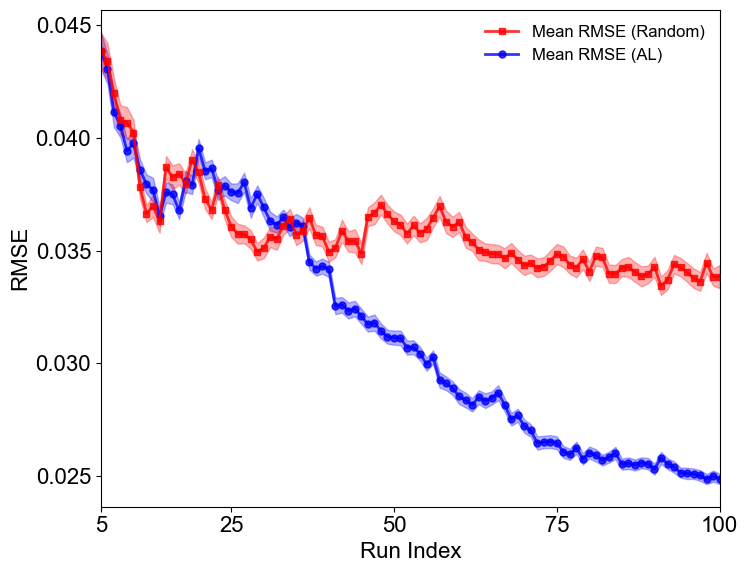

In [12]:
# ✅ LOAD DATA FOR BOTH CAMPAIGNS (from new per-trial JSON)
campaign_data = {}   # folder_name -> DataFrame indexed by run_index with columns: mean, sem
campaign_labels = {'Random_4D': 'Random', 'AL_4D': 'AL', 'Random_12D': 'Random', 'AL_12D': 'AL'}

for folder_name_current in campaigns_to_compare:

    json_file = f"campaigns/{folder_name_current}/RMSE.json"#RMSE_heldout_sets_correctmethod_RMSE_Only.json"

    if os.path.exists(json_file):
        with open(json_file) as f:
            results = json.load(f)

        trials = results["trials"]

        # --- limit to first N_TRIALS trials per campaign ---
        trial_keys = list(trials.keys())
        selected_keys = trial_keys

        print(f"    using {len(selected_keys)} of {len(trial_keys)} trials")

        # Collect rmse per run_index across the selected trials only
        per_index = {}   # run_index -> list of rmse
        for k in selected_keys:
            for r in trials[k]:
                per_index.setdefault(r["run_index"], []).append(r["rmse"])

        ######################################################################
        # --- outlier removal per run_index (IQR method) ---
        REMOVE_OUTLIERS = True
        IQR_K = 1.5   # 1.5 = standard, 3.0 = only extreme outliers

        def remove_outliers_iqr(vals, k=IQR_K):
            vals = np.asarray(vals, dtype=float)
            vals = vals[~np.isnan(vals)]
            if len(vals) < 4:          # too few points to define quartiles reliably
                return vals
            q1, q3 = np.percentile(vals, [25, 75])
            iqr = q3 - q1
            lo, hi = q1 - k * iqr, q3 + k * iqr
            return vals[(vals >= lo) & (vals <= hi)]

        if REMOVE_OUTLIERS:
            n_removed_total = 0
            for x in per_index:
                before = len(per_index[x])
                per_index[x] = list(remove_outliers_iqr(per_index[x]))
                n_removed_total += before - len(per_index[x])
            print(f"    removed {n_removed_total} outliers (IQR k={IQR_K})")

        ######################################################################
        # Gaussian filtering
        APPLY_GAUSSIAN = False
        GAUSSIAN_SIGMA = 2.0   # larger = smoother

        from scipy.ndimage import gaussian_filter1d

        if APPLY_GAUSSIAN:
            run_idx = sorted(per_index.keys())
            means_raw = np.array([np.mean(per_index[x]) for x in run_idx])
            sems_raw = np.array([np.std(per_index[x], ddof=1) / np.sqrt(len(per_index[x]))
                                    if len(per_index[x]) > 1 else 0.0
                                    for x in run_idx])

            means_smooth = gaussian_filter1d(means_raw, sigma=GAUSSIAN_SIGMA, mode='nearest')
            sems_smooth = gaussian_filter1d(sems_raw, sigma=GAUSSIAN_SIGMA, mode='nearest')

            means = means_smooth
            sems = sems_smooth
            print(f"    applied Gaussian filter (sigma={GAUSSIAN_SIGMA})")
        else:
            run_idx = sorted(per_index.keys())
            means = np.array([np.mean(per_index[x]) for x in run_idx])
            sems = np.array([np.std(per_index[x], ddof=1) / np.sqrt(len(per_index[x]))
                                if len(per_index[x]) > 1 else 0.0
                                for x in run_idx])

        ######################################################################

        df = pd.DataFrame({"rmse_all_exp": means,
                            "rmse_all_exp_sem": sems},
                            index=run_idx)

        campaign_data[folder_name_current] = df
        print(f"✅ Loaded {folder_name_current}: "
                f"{len(selected_keys)} trials, {len(run_idx)} run indices")

# ✅ PLOT: RMSE with SEM shaded band
plt.figure(figsize=(7.7, 6))

colors = ['blue', 'red']
markers = ['o', 's']

for i, folder_name_current in enumerate(campaigns_to_compare):
    if folder_name_current in campaign_data:
        data = campaign_data[folder_name_current]
        rmse_data = data['rmse_all_exp'].dropna()

        plt.plot(rmse_data.index, rmse_data.values,
                    color=colors[i], marker=markers[i], linewidth=2, markersize=5,
                    alpha=0.8, label=f'Mean RMSE ({campaign_labels[folder_name_current]})')

        sem_data = data.loc[rmse_data.index, 'rmse_all_exp_sem']
        plt.fill_between(rmse_data.index,
                            rmse_data.values - sem_data.values,
                            rmse_data.values + sem_data.values,
                            color=colors[i], alpha=0.3,
                        )

plt.xlabel('Run Index', fontsize=16)
plt.ylabel('RMSE', fontsize=16)
plt.tight_layout()

# reordering the labels
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 0]
plt.legend([handles[i] for i in order], [labels[i] for i in order],
            fontsize=12, frameon=False)

if campaigns_to_compare == ['AL_4D', 'Random_4D']:
    plt.xticks([5, 25, 50, 75, 100])
    plt.xlim([5, 100])
    plt.yticks([0.025, 0.03, 0.035, 0.04, 0.045])
elif campaigns_to_compare == ['AL_12D', 'Random_12D']:
    plt.xticks([15, 50, 100, 150, 200])
    plt.xlim([15, 200])
    plt.yticks([0.049, 0.051, 0.053, 0.055, 0.057])

# plot1_file = f"campaigns/comparison_rmse_all_exp_{'_vs_'.join(campaigns_to_compare)}.png"
# plt.savefig(plot1_file, dpi=300, bbox_inches='tight')

# plot1_file_pdf = plot1_file.replace(".png", ".pdf")
# plt.savefig(plot1_file_pdf, dpi=300, bbox_inches='tight')

plt.show()

# Precursor Dose Time Evolution (AL_4D Case)

Generating plot for max_run = 10


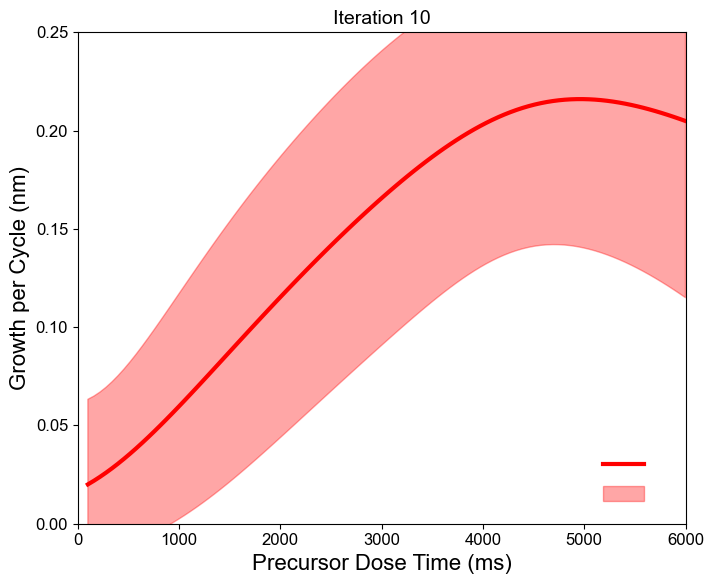

Generating plot for max_run = 20


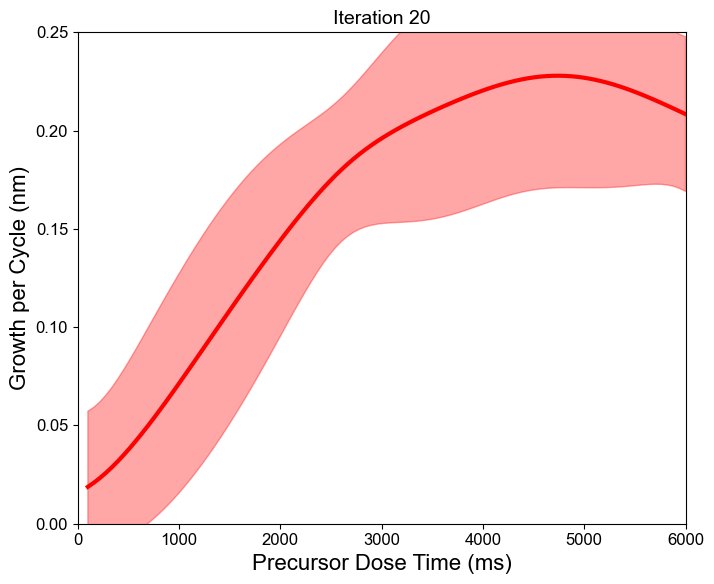

Generating plot for max_run = 99


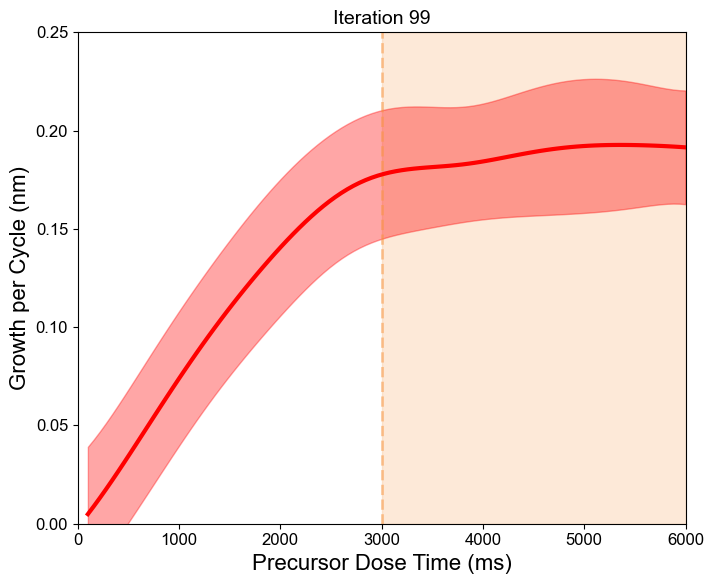

In [ ]:
# Set plot parameters
p = 'precursor_dose_time'
yerr = 0.011

# Set up input points for prediction
input_points_dict = {}
for param in config['modeled_params']:
    input_points_dict[param] = np.mean(config['param_limits'][param])

# Override specific values
input_points_dict['plasma_prep_time'] = 4000
input_points_dict['plasma_purge_time'] = 4000
input_points_dict['ALD_purge_time'] = 6000

# Create prediction points
p0, p1 = config['param_limits'][p]
input_points_dict[p] = np.linspace(p0, p1, 100)
prediction_points_df = pd.DataFrame(input_points_dict, columns=config['modeled_params'])

# Set matplotlib parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Arial'],
    'font.size': 12
})

# Loop through different max_run values
max_run_values = [10, 20, 99] # 30, 40, 50, 60, 70, 80, 90

# max_run_values = [99]

for max_run in max_run_values:
    
    # Create figure
    fig = plt.figure(figsize=(7.3, 6))
    
    # Get data
    runs = merged_df.iloc[:max_run]
    gpmodel = merged_df.at[max_run, 'gpmodel']
    
    # Get posterior predictions
    f, v = gpmodel.posterior(prediction_points_df)
    

    if max_run==99:
        
        # Option 1: plasma at a higher position (more orange)
        shade_color = plt.cm.plasma(0.75)  # ~#f1844b, warm orange

        # Shade the ALD window region
        plt.axvspan(3000, 6000, alpha=0.2, color=shade_color, label=' ', zorder=0)  # ALD Window
        plt.axvline(3000, color=shade_color, linestyle='--',  alpha=0.5, linewidth=2)
    

    # Plot GP prediction
    plt.plot(prediction_points_df[p], f, color="red", label=" ", linewidth = 3 ) # GP Prediction")  "darkblue"
    plt.xlabel("Precursor Dose Time (ms)", fontsize=16)
    plt.ylabel("Growth per Cycle (nm)", fontsize=16)
    plt.fill_between(prediction_points_df[p], f - 2. * v, f + 2. * v, 
                     alpha=0.35, color="red", label=" " ) # Posterior Covariance")
    
    
    
    # Plot settings
    plt.ylim(0, 0.25)
    plt.xlim(0, 6000)
    plt.tick_params(axis="y") #, direction="in")
    plt.tick_params(axis="x")#, direction="in")
    # plt.tick_params(top=True, right=True)
    
    if max_run==10:
        plt.legend(loc='lower right',frameon = False, fontsize =15)

   
    # Add title with iteration number
    plt.title(f"Iteration {max_run}", fontsize=14)
    
    plt.tight_layout()
    
    plt.show()
    


# 4D Plots (AL_4D case, can be used for the Random_4D)

In [ ]:
# Retraining the final gpmodel with all the data to make sure it is trained on dat

gpmodel_final = GPmodel(merged_df, 
                        input_names=config['modeled_params'], output_name='dep_rate_mean',
                        parameter_space_limits=parameter_space_limits,
                        output_deviation_variable='dep_rate_deviation',
                        #prev_trained_GP_hps=np.array(merged_df.at[i,'current_trained_hps']), # Comment this out if you want to retrain the model
                        train_method="global",
                        train_max_iter=4000)
        
gpmodel_final.my_gpo.get_hyperparameters()

In [ ]:
def plot(X, Y, Z, W, mean_colorbar_limits=None, data=None, var_name=None,
         lower_bounds=None, upper_bounds=None,
         colorbar_title=None, plt_idx=None,
         line_x=None, line_z=None, line_color='black', line_width=8):

    axis_title_size = 22
    axis_ticks_size = 15

    var_names_3D = [element for i, element in enumerate(var_name) if i != plt_idx]
    lower_bounds_3D = [element for i, element in enumerate(lower_bounds) if i != plt_idx]
    upper_bounds_3D = [element for i, element in enumerate(upper_bounds) if i != plt_idx]
    y_data = data[:, 4]
    data_3D = np.delete(data[:, 0:4], plt_idx, axis=1)

    fig = go.Figure()

    if data is not None:
        fig.add_trace(go.Scatter3d(
            x=data_3D[:, 0],
            y=data_3D[:, 1],
            z=data_3D[:, 2],
            mode='markers',
            marker=dict(
                size=15,
                color=y_data,
                opacity=0.8,
                colorscale="Plasma",
                cmin=mean_colorbar_limits[0],
                cmax=mean_colorbar_limits[1]),
            showlegend=False))

        fig.add_trace(go.Scatter3d(
            x=data_3D[:, 0],
            y=data_3D[:, 1],
            z=data_3D[:, 2],
            mode='markers',
            marker=dict(
                size=17,
                color='black',
                symbol='circle-open',
                line=dict(width=3)
            ),
            showlegend=False
        ))

    # --- NEW: add a straight line at fixed x, z, spanning full y-range ---
    if line_x is not None and line_z is not None:
        fig.add_trace(go.Scatter3d(
            x=[line_x, line_x],
            y=[lower_bounds_3D[1], upper_bounds_3D[1]],
            z=[line_z, line_z],
            # mode='lines',
            line=dict(color=line_color, width=line_width),
            showlegend=False
        ))
    # ----------------------------------------------------------------------

    for i in range(0, len(Z[0, 0, :]), 3):
        fig.add_trace(go.Surface(
            x=X[:, :, i],
            y=Y[:, :, i],
            z=Z[:, :, i],
            surfacecolor=W[:, :, i],
            colorscale='Plasma',
            cmin=mean_colorbar_limits[0],
            cmax=mean_colorbar_limits[1],
            opacity=0.85,
            colorbar=dict(
                title=colorbar_title,
                ticks='outside',
                tickfont=dict(size=axis_ticks_size * 1.5, color='black'),
                len=0.8)))

    fig.update_layout(
        width=1000,
        height=1000,
        margin=dict(l=65, r=50, b=65, t=90),
        scene=dict(
            xaxis_title=  var_names_3D[0],
            yaxis_title=  var_names_3D[1],
            zaxis_title=  var_names_3D[2],
            xaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                range=[lower_bounds_3D[0], upper_bounds_3D[0]]
            ),
            yaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                range=[lower_bounds_3D[1], upper_bounds_3D[1]]
            ),
            zaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                range=[lower_bounds_3D[2] * 0.99, upper_bounds_3D[2] * 1.01]
            ),
            aspectmode='cube',
            camera=dict(
                eye=dict(x=-1.5, y=1.5, z=1.5)
            )))

    fig.show()

# Plotting the results on a 3D plot
def plot_Uncertainty(X, Y, Z, W, var_colorbar_limits,var_name = None, lower_bounds = None, upper_bounds = None , plt_idx = None):
    fig = go.Figure()

    axis_title_size = 30
    axis_ticks_size = 15

    var_names_3D = [element for i, element in enumerate(var_name) if i != plt_idx]
    lower_bounds_3D = [element for i, element in enumerate(lower_bounds) if i != plt_idx]
    upper_bounds_3D = [element for i, element in enumerate(upper_bounds) if i != plt_idx]


    for i in range(0, len(Z[0, 0, :]),3):
        fig.add_trace(go.Surface(
            x=X[:, :, i],
            y=Y[:, :, i],
            z=Z[:, :, i],
            surfacecolor=W[:, :, i],
            cmin=var_colorbar_limits[0],
            cmax=var_colorbar_limits[1],
            colorscale='Viridis',  # Set the Viridis colormap
            colorbar= dict(
                title=' ',
                tickvals=[0.007,0.009,0.011,0.013,0.015],
                ticks='outside',
                tickfont=dict(size=axis_ticks_size*1.5),
                len=0.8,  # Adjust the length of the color bar (0.5 represents half the length)
            )
        ))

    fig.update_layout(
        width=1000,
        height=1000,
        margin=dict(l=65, r=50, b=65, t=90),
        scene=dict(
            xaxis_title=  var_names_3D[0],
            yaxis_title=  var_names_3D[1],
            zaxis_title=  var_names_3D[2],
            xaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                range=[lower_bounds_3D[0], upper_bounds_3D[0]]  # Set the x-axis range
                ),
            yaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                range=[lower_bounds_3D[1], upper_bounds_3D[1]]  # Set the x-axis range
                ),
            zaxis=dict(
                title_font=dict(size=axis_title_size, color='black'),
                tickfont=dict(size=axis_ticks_size, color='black'),
                range=[lower_bounds_3D[2]*0.99, upper_bounds_3D[2]*1.01]
                ),

        aspectmode='cube',    
        camera=dict(
            eye=dict(x=-1.5, y=1.5, z=1.5)  # Adjust these values to control zoom
        )
        )
    )
    fig.show()

In [ ]:
#Define parameter space:

var_names = config['modeled_params']
fixed_var_name = 'ALD_purge_time'
fixed_var_idx = var_names.index(fixed_var_name)

fixed_var_level = 6000. # Fixed value for lead parameter:  'ALD_purge_time' = [10, 2000,4000,6000]

tolerance = 1000

num_points = 10

lower_bounds = []
upper_bounds = []
for param in var_names:
     lower_bounds.append(config['param_limits'][param][0])
     upper_bounds.append(config['param_limits'][param][1])

# Indices for each variable
vary_indices = [i for i in range(4) if i != fixed_var_idx]

#################################################
# Parameter Space Grid
# Prepare grid axes for the three variables to vary
grid_axes = [np.linspace(lower_bounds[i], upper_bounds[i], num_points) for i in vary_indices]

X1, X2, X3 = np.meshgrid(*grid_axes, indexing='ij')

# Flatten the mesh to get all combinations
points = np.vstack([X1.ravel(), X2.ravel(), X3.ravel()]).T

# Insert the fixed variable at fixed_var_idx
my_space = np.empty((points.shape[0], 4))
for i, idx in enumerate(vary_indices):
    my_space[:, idx] = points[:, i]
my_space[:, fixed_var_idx] = fixed_var_level  # fixed value for lead parameter
my_space_df = pd.DataFrame(my_space, columns=var_names)
#################################################

gpmodel_final = merged_df ['gpmodel'].values[-1]

# Doing the predictions
f, v = gpmodel_final.posterior(my_space_df)
f_re = f.reshape(num_points, num_points, num_points)      # This is the prediction


###################################################################################
# comment out if no actual data used
# get measured datapoints
x_data_norm = gpmodel_final.my_gpo.x_data
x_data = gpmodel_final.scaler.inverse_transform(x_data_norm)
y_data = gpmodel_final.my_gpo.y_data
# select data within tolerance of selected plane
mask = np.abs(x_data[:, fixed_var_idx].astype(float) - fixed_var_level) < tolerance
data = np.column_stack([
    x_data[mask, :].astype(float),
    y_data[mask]
])

print("Number of data points within tolerance:", data.shape[0])

#####################################################################################

mean_colorbar_limits = np.array([0, y_data.max()])


plot(X1, X2, X3, f_re,
     mean_colorbar_limits=mean_colorbar_limits,
     data=data,
     lower_bounds=lower_bounds,
     upper_bounds=upper_bounds,
     var_name=var_names,
     colorbar_title="GR (nm)",
     plt_idx=fixed_var_idx,
     line_x=3920,
     line_z=4070,
     line_width = 50,
     line_color = "red")

Number of data points within tolerance: 35
0.0015001539529558572 0.24501150204231392


In [ ]:
# uncertainty plot

v_re = v.reshape(num_points, num_points,num_points)

var_colorbar_limits = np.array([0.007, 0.015])

plot_Uncertainty(X = X1, 
                 Y = X2,
                 Z = X3, 
                 W = v_re,
                 var_name=var_names,
                 lower_bounds = lower_bounds,
                 upper_bounds = upper_bounds,
                 var_colorbar_limits = var_colorbar_limits, 
                 plt_idx = fixed_var_idx
                 )


[0.00798995 0.0148581 ]


# Sweep Slices (AL_12D Case)

In [ ]:
# Retraining the final gpmodel with all the data to make sure it is trained on dat

gpmodel_final = GPmodel(merged_df, 
                        input_names=config['modeled_params'], output_name='dep_rate_mean',
                        parameter_space_limits=parameter_space_limits,
                        output_deviation_variable='dep_rate_deviation',
                        #prev_trained_GP_hps=np.array(merged_df.at[i,'current_trained_hps']), # Comment this out if you want to retrain the model
                        train_method="global",
                        train_max_iter=4000)
        
gpmodel_final.my_gpo.get_hyperparameters()

✓ Loaded precursor_dose_time_sweep.json → sweep_param: ['precursor_dose_time']
✓ Loaded plasma_purge_time_sweep.json → sweep_param: ['plasma_purge_time']
✓ Loaded process_pressure_sweep.json → sweep_param: ['process_pressure']


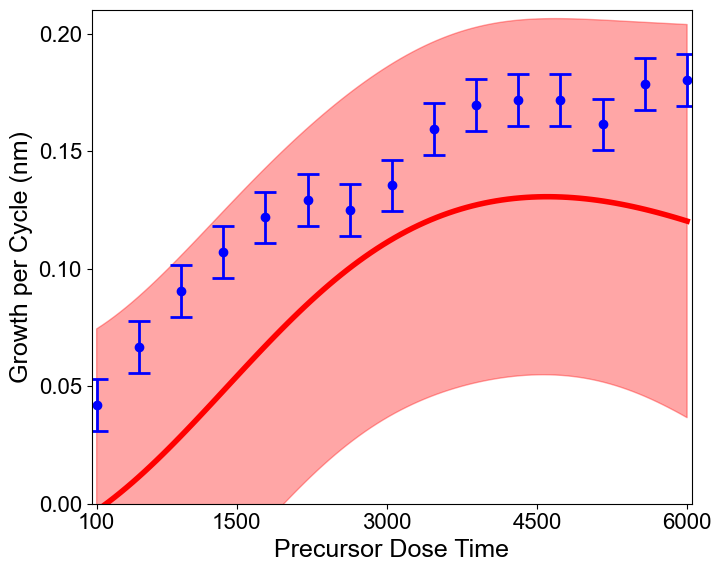

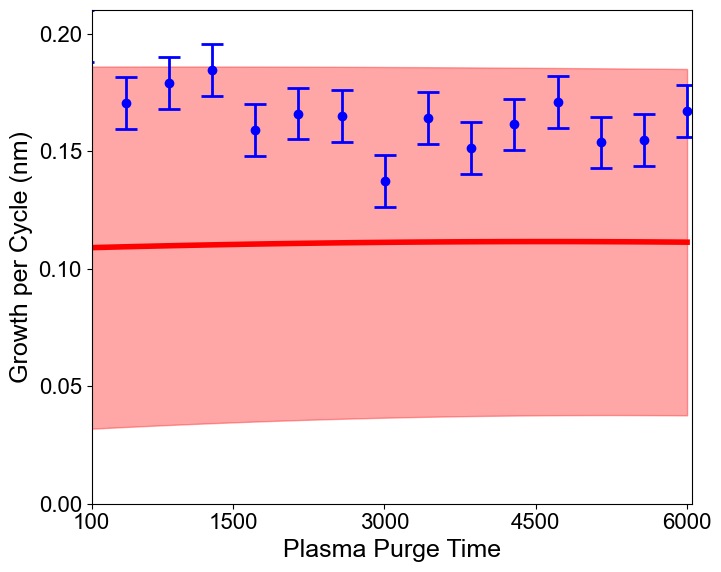

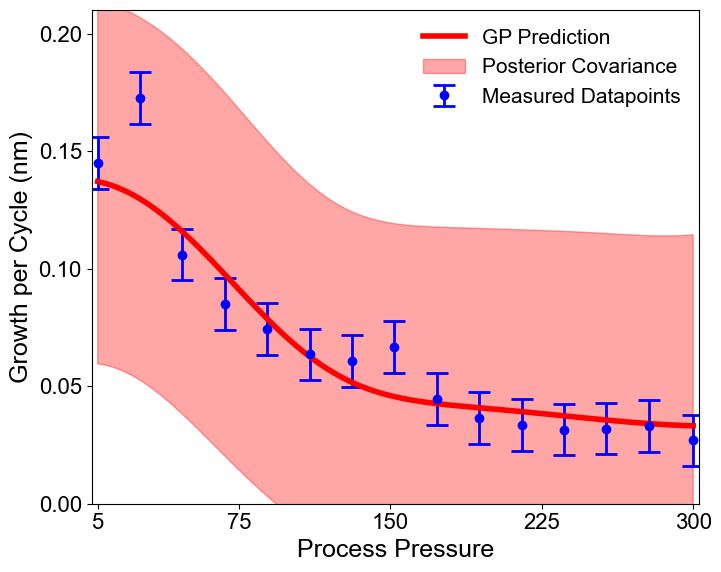

In [27]:
SWEEPS_FOLDER = "Sweeps"  # adjust path if needed, e.g. "Data/Sweeps"

# ── Load the three sweeps directly by filename ────────────────────────────────
def load_sweep(filename, sweeps_folder=SWEEPS_FOLDER):
    fpath = os.path.join(sweeps_folder, filename)
    with open(fpath, 'r') as f:
        sweep = json.load(f)
    print(f"✓ Loaded {filename} → sweep_param: {sweep['config']['sweep_param']}")
    return sweep, fpath

sweep_precursor_dose, fpath_precursor_dose = load_sweep("precursor_dose_time_sweep.json")
sweep_plasma_purge, fpath_plasma_purge     = load_sweep("plasma_purge_time_sweep.json")
sweep_process_pressure, fpath_process_pressure = load_sweep("process_pressure_sweep.json")


# ── Plotting function (unchanged) ─────────────────────────────────────────────
def plot_sweep_gp(sweep, sweep_param, gpmodel, config, legend=True,
                 xlabel=None, x_ticks=None, x_lim=None, title=None):

    runs_sweep = pd.DataFrame(sweep['runs'])

    input_points_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
    p0, p1 = sweep['config']['param_limits'][sweep_param]
    sweep_x = np.linspace(p0, p1, 100)
    input_points_dict[sweep_param] = sweep_x
    f, f_std = gpmodel.posterior(pd.DataFrame(input_points_dict, columns=config['modeled_params']))

    actual_dict = {p: sweep['config']['params'][p] for p in config['modeled_params']}
    actual_dict[sweep_param] = runs_sweep[sweep_param].values
    f_actual, _ = gpmodel.posterior(pd.DataFrame(actual_dict, columns=config['modeled_params']))

    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.sans-serif': ['Arial'],
    })

    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.errorbar(runs_sweep[sweep_param], runs_sweep['dep_rate_mean'],
                yerr=0.011, fmt='o', label='Measured Datapoints', color='blue',
                capsize=8, capthick=2, elinewidth=2)
    ax.plot(sweep_x, f, color='red', label='GP Prediction', linewidth=4)
    ax.fill_between(sweep_x, f - 2*f_std, f + 2*f_std,
                    alpha=0.35, color='red', label='Posterior Covariance')
    ax.set_xlabel(xlabel or sweep_param, fontsize=18)
    ax.set_ylabel('Growth per Cycle (nm)', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
    if x_lim is not None:
        ax.set_xlim(x_lim)
    ax.set_ylim(0.0, 0.21)
    ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20])
    if legend:
        ax.legend(fontsize=15, loc='best', frameon=False)
    if title:
        ax.set_title(title, fontsize=15)
    plt.tight_layout()
    plt.show()

    return fig, ax


# ── Plot Precursor Dose Time ───────────────────────────────────────────────────
fig_precursor, ax_precursor = plot_sweep_gp(
    sweep_precursor_dose, 'precursor_dose_time', gpmodel_final, config,
    xlabel='Precursor Dose Time',
    x_ticks=[100, 1500, 3000, 4500, 6000],
    x_lim=[50, 6050],
    legend=False,
)

# ── Plot Plasma Purge Time ─────────────────────────────────────────────────────
fig_purge, ax_purge = plot_sweep_gp(
    sweep_plasma_purge, 'plasma_purge_time', gpmodel_final, config,
    xlabel='Plasma Purge Time',
    x_ticks=[100, 1500, 3000, 4500, 6000],
    x_lim=[100, 6050],
    legend=False,
)

# ── Plot Process Pressure ──────────────────────────────────────────────────────
fig_pressure, ax_pressure = plot_sweep_gp(
    sweep_process_pressure, 'process_pressure', gpmodel_final, config,
    xlabel='Process Pressure',
    x_ticks=[5, 75, 150, 225, 300],
    x_lim=[2, 303],
    legend=True,
)

# Identify the parameters with minimum total processing time (BO_12D and Random_12D)

In [ ]:
from scipy.optimize import differential_evolution, NonlinearConstraint
import numpy as np
import pandas as pd

# Convert parameter limits to bounds format - MAINTAINING ORDER
bounds = [config['param_limits'][param] for param in config['modeled_params']]

# Verify bounds order matches modeled_params
print("Parameter order verification:")
for i, param in enumerate(config['modeled_params']):
    print(f"{i}: {param} -> bounds: {bounds[i]}")

# Set your target deposition rate and tolerance
r_target = 0.2
epsilon = 0.1 * abs(r_target)

# Define which parameters contribute to total time
time_param_indices = [
    config['modeled_params'].index('plasma_duration'),
    config['modeled_params'].index('precursor_dose_time'),
    config['modeled_params'].index('ALD_prep_time'),
    config['modeled_params'].index('ALD_purge_time'),
    config['modeled_params'].index('plasma_prep_time'),
    config['modeled_params'].index('plasma_purge_time'),
]

def total_time(x):
    """Sum of time-based parameters"""
    return sum(x[i] for i in time_param_indices)

def con_fun(x):
    """Constraint: predicted rate should be within epsilon of target"""
    prediction_df = pd.DataFrame([x], columns=config["modeled_params"])
    f, f_std = gpmodel_final.posterior(prediction_df)
    return epsilon - abs(f[0] - r_target)

# Test the constraint function with a known point first
test_x = [np.mean(b) for b in bounds]
print("\nTesting constraint with midpoint values...")
print(f"Constraint value: {con_fun(test_x)}")

nonlin_con = NonlinearConstraint(con_fun, 0, np.inf)

result = differential_evolution(
    total_time,
    bounds=bounds,
    constraints=(nonlin_con,),
    seed=42,
    maxiter=1000,
    atol=1e-2,
    tol=1e-3
)

if result.success:
    opt_params = result.x
    print("\nOptimal process parameters:")
    for param, value in zip(config['modeled_params'], opt_params):
        print(f"  {param}: {value:.2f}")
    print(f"\nTotal process time: {total_time(opt_params):.2f}")
    
    prediction_df = pd.DataFrame([opt_params], columns=config["modeled_params"])
    f, f_std = gpmodel_final.posterior(prediction_df)
    print(f"Expected deposition rate: {f[0]:.4f} ± {f_std[0]:.4f}")
    print(f"Target rate: {r_target} ± {epsilon}")
else:
    print("No feasible solution found:", result.message)

Parameter order verification:
0: plasma_duration -> bounds: [100, 5000]
1: precursor_dose_time -> bounds: [100, 5000]
2: process_pressure -> bounds: [5, 300]
3: ALD_purge_time -> bounds: [5, 5000]
4: plasma_pressure -> bounds: [25, 300]
5: RF_power_setpoint -> bounds: [25, 300]
6: plasma_prep_time -> bounds: [10, 5000]
7: plasma_purge_time -> bounds: [10, 10000]
8: H2_plasma_flow_rate -> bounds: [25, 100]
9: Ar_process_flow_rate -> bounds: [25, 90]
10: ALD_purge_flow_rate -> bounds: [1, 20]
11: ALD_prep_time -> bounds: [100, 4000]

Testing constraint with midpoint values...
Constraint value: -0.13236871212976353

Optimal process parameters:
  plasma_duration: 100.00
  precursor_dose_time: 4412.34
  process_pressure: 10.39
  ALD_purge_time: 5.23
  plasma_pressure: 277.47
  RF_power_setpoint: 299.74
  plasma_prep_time: 1568.33
  plasma_purge_time: 10.12
  H2_plasma_flow_rate: 99.80
  Ar_process_flow_rate: 25.01
  ALD_purge_flow_rate: 18.89
  ALD_prep_time: 100.28

Total process time: 619

# SHAP Analysis (AL_4D, AL_12D)

Test predictions: [0.04199682 0.14258654 0.06815954]
Shape: (3,)


  0%|          | 0/100 [00:00<?, ?it/s]

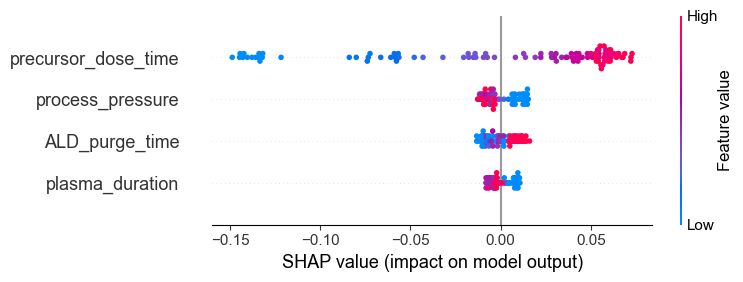

In [ ]:
# wrapping around the gpcam model
import shap


X_train_SHAP = gpmodel_final.my_gpo.x_data
y_train_SHAP = gpmodel_final.my_gpo.y_data

# ── Wrap the gpCAM posterior mean ─────────────────────────────────────────────
# KernelExplainer needs a function: array (n_samples, n_features) → array (n_samples,)
def gpcam_predict(X):
    X = np.array(X)  # SHAP sometimes passes pandas DataFrames or lists
    result = gpmodel_final.my_gpo.posterior_mean(X)
    return result["m(x)"]

# ── Quick sanity check before running SHAP ────────────────────────────────────
test_preds = gpcam_predict(X_train_SHAP[:3])
print("Test predictions:", test_preds)
print("Shape:", test_preds.shape)  # should be (3,)

# # ── SHAP explainer ────────────────────────────────────────────────────────────
explainer = shap.KernelExplainer(gpcam_predict, X_train_SHAP)

# nsamples controls accuracy vs speed — increase to 1024+ for final results
shap_values = explainer.shap_values(X_train_SHAP, nsamples=512)

# ── Feature names ─────────────────────────────────────────────────────────────
feature_names = [
    'plasma_duration', 'precursor_dose_time', 'process_pressure',
    'ALD_purge_time', 'plasma_pressure', 'RF_power_setpoint',
    'plasma_prep_time', 'plasma_purge_time', 'H2_plasma_flow_rate',
    'Ar_process_flow_rate', 'ALD_purge_flow_rate', 'ALD_prep_time'
]

# ── Plots ─────────────────────────────────────────────────────────────────────
# Beeswarm: shows distribution of SHAP values per feature
shap.summary_plot(shap_values, X_train_SHAP, feature_names=feature_names)

# Bar: global importance ranked by mean |SHAP|
# shap.summary_plot(shap_values, X_train_SHAP, feature_names=feature_names, plot_type="bar")
